# Case Study 2: Credit Card Fraud Detection Using XGBoost and SMOTE

**Objective:** Build a binary classifier that flags fraudulent transactions, using XGBoost trained on a heavily imbalanced dataset, with SMOTE oversampling to address the class imbalance and threshold tuning to control the precision/recall trade-off.

**Dataset:** [IEEE-CIS Fraud Detection](https://www.kaggle.com/c/ieee-fraud-detection) (Kaggle) — real-world e-commerce transaction data with anonymized transaction and identity/device features, and a binary `isFraud` label.

**Problem type:** Binary classification (Fraud = 1, Legitimate = 0), heavily imbalanced.

**Model requirement:** XGBoost + SMOTE (training data only) + threshold tuning + feature importance interpretation.


## 1. Problem Statement

Credit card fraud detection is a binary classification problem: given the details of a transaction, decide whether it is fraudulent or legitimate. Two things make this problem harder than a typical classification task:

- **Severe class imbalance.** The overwhelming majority of transactions are legitimate; fraudulent transactions are rare. A model that simply predicts "legitimate" for everything would already achieve very high *accuracy* while being completely useless — it would catch zero fraud.
- **Asymmetric consequences.** A **false negative** (missed fraud) results in direct financial loss and a bad customer experience once the fraud is discovered. A **false positive** (a legitimate transaction wrongly flagged) causes friction for a genuine customer — a declined purchase, a blocked card, an unnecessary review — which has its own cost in customer trust and manual review workload. Because these two error types are not equally costly, we need a way to move between them deliberately, which is what the threshold-tuning section later in this notebook is for.


## 2. Import Libraries

In [1]:
# Uncomment if running in a fresh environment without these installed
# !pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn xgboost --quiet

import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 3. Load Dataset

**Setup note:** This notebook expects either a folder named `ieee_data/` containing `train_transaction.csv` and `train_identity.csv`, or the original `ieee-fraud-detection.zip` placed in the same directory as this notebook (it will be extracted automatically). We only need the **train** files — the Kaggle test files have no `isFraud` labels, so we create our own held-out test split from the labeled training data instead.

**Memory strategy (documented, reproducible):** The full transaction table has **394 columns**, including 339 anonymized `V1`–`V339` engineered features that are known (from the competition's public discussion) to be highly redundant/correlated blocks. Loading and one-hot-encoding all of them, plus the identity table, is unnecessary and risks running out of memory on a normal laptop. Instead we:

1. Keep all of the non-`V` columns (transaction amount, card/address/device info, the `C`, `D`, and `M` feature blocks).
2. Take **every 10th `V` column** (`V1, V11, V21, ..., V331`) — a deterministic, reproducible way to keep a representative sample of that feature block without keeping all 339 highly-correlated columns.
3. Load numeric columns as `float32` instead of the pandas default `float64`, halving their memory footprint.
4. From the identity table, keep only the low-cardinality categorical columns (device type and a handful of `id_` match/verification flags) and skip free-text, high-cardinality columns such as `DeviceInfo`, `id_30` (OS string), `id_31` (browser string) and `id_33` (screen resolution) — one-hot encoding these would create thousands of extra sparse columns for very little benefit.

If you want to use a different subset of `V` columns, only the list `v_cols_selected` below needs to change.


In [2]:
DATA_DIR = 'ieee_data'
ZIP_CANDIDATES = ['ieee-fraud-detection.zip']

def locate_file(filename, search_dirs=('.', DATA_DIR)):
    for d in search_dirs:
        path = os.path.join(d, filename)
        if os.path.exists(path):
            return path
    return None

transaction_path = locate_file('train_transaction.csv')
identity_path = locate_file('train_identity.csv')

if transaction_path is None:
    for zc in ZIP_CANDIDATES:
        if os.path.exists(zc):
            os.makedirs(DATA_DIR, exist_ok=True)
            with zipfile.ZipFile(zc, 'r') as z:
                # Only extract the two labeled training files we actually need
                for member in ['train_transaction.csv', 'train_identity.csv']:
                    if member in z.namelist():
                        z.extract(member, DATA_DIR)
            transaction_path = locate_file('train_transaction.csv')
            identity_path = locate_file('train_identity.csv')
            break

if transaction_path is None:
    raise FileNotFoundError(
        "Could not find 'train_transaction.csv'. Place the extracted dataset in an "
        "'ieee_data' folder next to this notebook, or place the original "
        "'ieee-fraud-detection.zip' in the same directory as this notebook."
    )

print("Transaction file:", transaction_path)
print("Identity file:   ", identity_path)

Transaction file: ieee_data/train_transaction.csv
Identity file:    ieee_data/train_identity.csv


In [3]:
# --- Documented, deterministic column selection (see explanation above) ---
base_cols = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD',
             'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
             'addr1', 'addr2', 'dist1', 'P_emaildomain']
c_cols = [f'C{i}' for i in range(1, 15)]
d_cols = [f'D{i}' for i in range(1, 16)]
m_cols = [f'M{i}' for i in range(1, 10)]
v_cols_all = [f'V{i}' for i in range(1, 340)]
v_cols_selected = v_cols_all[::10]  # every 10th V column: 34 of the 339 V columns

usecols = base_cols + c_cols + d_cols + m_cols + v_cols_selected
print(f"Loading {len(usecols)} of the original 394 transaction columns "
      f"(dropped: R_emaildomain, dist2 [>90% missing], TransactionID after merge, "
      f"and {339 - len(v_cols_selected)} of the 339 V-columns).")

float32_cols = c_cols + d_cols + v_cols_selected + \
    ['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1']
dtype_map = {c: 'float32' for c in float32_cols}

t0 = time.time()
transactions = pd.read_csv(transaction_path, usecols=usecols, dtype=dtype_map)
print(f"Loaded transactions: {transactions.shape} in {time.time()-t0:.1f}s "
      f"({transactions.memory_usage(deep=True).sum()/1e6:.0f} MB)")

Loading 87 of the original 394 transaction columns (dropped: R_emaildomain, dist2 [>90% missing], TransactionID after merge, and 305 of the 339 V-columns).


Loaded transactions: (590540, 87) in 5.1s (526 MB)


In [4]:
identity_cols = ['TransactionID', 'DeviceType', 'id_12', 'id_15', 'id_16',
                 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38']
identity = pd.read_csv(identity_path, usecols=identity_cols)
print(f"Loaded identity: {identity.shape}")
print(f"({identity.shape[0]} of {transactions.shape[0]} transactions have identity/device data, "
      f"{identity.shape[0]/transactions.shape[0]*100:.1f}%)")

# Left join: most transactions do NOT have a matching identity row, which is expected
df = transactions.merge(identity, on='TransactionID', how='left')
print("Merged shape:", df.shape)
del transactions, identity

Loaded identity: (144233, 11)
(144233 of 590540 transactions have identity/device data, 24.4%)
Merged shape: (590540, 97)


## 4. Data Inspection

In [5]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,P_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,...,V141,V151,V161,V171,V181,V191,V201,V211,V221,V231,V241,V251,V261,V271,V281,V291,V301,V311,V321,V331,id_12,id_15,id_16,id_28,id_29,id_35,id_36,id_37,id_38,DeviceType
0,2987000,0,86400,68.5,W,13926.0,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755.0,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,gmail.com,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663.0,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,outlook.com,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132.0,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,yahoo.com,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497.0,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,gmail.com,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,0.0,49.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NotFound,New,NotFound,New,NotFound,T,F,T,T,mobile


In [6]:
df.dtypes.value_counts()

float32    71
str        23
int64       3
Name: count, dtype: int64

In [7]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.head(15).to_frame('missing_pct').round(1)

,missing_pct
D7,93.4
D13,89.5
D14,89.5
D12,89.0
D6,87.6
D8,87.3
D9,87.3
V141,86.1
V161,86.1
V151,86.1


In [8]:
df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,...,V41,V51,V61,V71,V81,V91,V101,V111,V121,V131,V141,V151,V161,V171,V181,V191,V201,V211,V221,V231,V241,V251,V261,V271,V281,V291,V301,V311,V321,V331
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,...,421571.000000,421571.000000,513444.000000,513444.000000,501376.000000,501376.000000,590226.000000,590226.000000,590226.000000,590226.000000,81945.000000,81951.000000,81945.000000,139819.000000,139631.000000,139631.000000,139819.000000,139631.000000,141416.000000,130430.000000,130430.000000,141416.000000,130430.000000,141416.000000,589271.000000,590528.000000,589271.000000,590528.000000,590528.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734375,362.555511,153.194931,199.278900,290.733795,86.800629,118.502182,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144575,4.480240,5.240343,10.241521,4.076227,32.539921,8.295215,94.347572,169.563232,28.343348,140.002441,42.335964,...,0.999269,0.170579,0.829785,0.140639,0.152696,0.420461,0.889249,1.002563,1.004276,31.133301,0.037696,6.460190,4.843938,1.690907,0.253332,1.058984,1.159106,385.137024,1.274912,0.765506,1.000238,0.794231,1.107161,9.445133,0.087783,1.659811,0.052002,4.202175,28.326582,721.741882
std,1.704744e+05,0.183755,4.617224e+06,239.162521,4901.169922,157.793243,11.336444,41.244453,101.741074,2.690624,371.872009,133.569016,154.668900,0.150536,68.848457,25.786976,71.508469,61.727303,95.378571,16.674896,95.581444,94.336288,86.666214,129.364853,49.544262,157.660385,177.315872,62.384724,191.096771,89.000145,...,0.027020,0.403899,0.436617,0.364303,0.452298,0.561865,20.582571,0.070830,0.067097,161.161255,0.215133,15.232324,58.929756,2.444748,1.248974,0.677527,1.418618,4541.837891,2.728792,8.877118,0.022663,0.501240,1.323231,74.147728,0.512748,16.252539,0.318310,102.374939,382.053162,6217.223633
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-122.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.320999,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,26.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769001,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,8.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000,3.000000,97.000000,8.000000,26.000000,10.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.

## 5. Verify and Explore the Target (`isFraud`)

We confirm the target column is `isFraud`, coded `0` = legitimate and `1` = fraud, and quantify exactly how imbalanced it is.


In [9]:
print(df['isFraud'].value_counts())
print()
n_legit = (df['isFraud'] == 0).sum()
n_fraud = (df['isFraud'] == 1).sum()
fraud_pct = n_fraud / len(df) * 100
print(f"Legitimate transactions: {n_legit}")
print(f"Fraudulent transactions: {n_fraud}")
print(f"Fraud percentage: {fraud_pct:.2f}%")

isFraud
0    569877
1     20663
Name: count, dtype: int64

Legitimate transactions: 569877
Fraudulent transactions: 20663
Fraud percentage: 3.50%


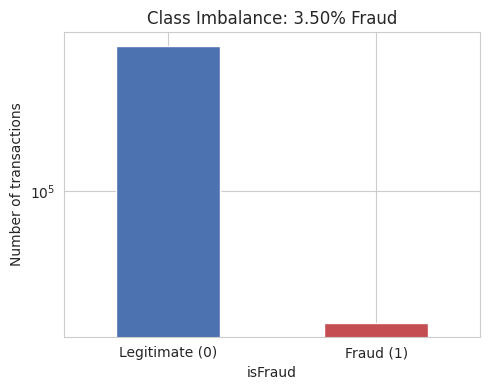

The dataset is heavily imbalanced: legitimate transactions outnumber fraudulent ones roughly 28-to-1. Note the log scale on the y-axis above — on a linear scale the fraud bar would barely be visible.


In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
df['isFraud'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0', '#C44E52'], ax=ax)
ax.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
ax.set_ylabel('Number of transactions')
ax.set_title(f'Class Imbalance: {fraud_pct:.2f}% Fraud')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"The dataset is heavily imbalanced: legitimate transactions outnumber fraudulent ones "
      f"roughly {n_legit/n_fraud:.0f}-to-1. Note the log scale on the y-axis above — on a linear "
      f"scale the fraud bar would barely be visible.")

## 6. Data Preprocessing

**Feature engineering:** `TransactionDT` is a time delta (in seconds) from a fixed reference point rather than a real timestamp, so absolute values aren't directly meaningful — but the time *of day* a transaction occurs is a plausible fraud signal, so we derive an `Transaction_hour` feature (`0`–`23`) from it and drop the raw column along with the now-unneeded `TransactionID`.

**Categorical encoding:** `P_emaildomain` has dozens of distinct email domains with a long tail of rare ones. We bucket it into the 10 most frequent domains plus `'Other'` / `'Missing'`, rather than one-hot encoding every domain individually.

**Missing values:** numeric features are median-imputed, categorical features are imputed with their most frequent value (or `'Missing'` bucket), then categorical features are one-hot encoded and numeric features are standardized — all combined in a single `ColumnTransformer` so the exact same transformation applies to train and test data.


In [11]:
df['Transaction_hour'] = ((df['TransactionDT'] // 3600) % 24).astype('float32')
df = df.drop(columns=['TransactionDT', 'TransactionID'])

top_domains = df['P_emaildomain'].value_counts().head(10).index.tolist()
def bucket_email(x):
    if pd.isna(x):
        return 'Missing'
    return x if x in top_domains else 'Other'
df['P_emaildomain'] = df['P_emaildomain'].apply(bucket_email)
print(df['P_emaildomain'].value_counts())

P_emaildomain
gmail.com        228355
yahoo.com        100934
Missing           94456
hotmail.com       45250
anonymous.com     36998
Other             28882
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
Name: count, dtype: int64


In [12]:
target = 'isFraud'
y = df[target].astype(int)
X = df.drop(columns=[target])

numeric_features = [c for c in X.columns if X[c].dtype.kind in 'if']
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"Numeric features ({len(numeric_features)})")
print(f"Categorical features ({len(categorical_features)}):", categorical_features)

Numeric features (72)
Categorical features (23): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType']


In [13]:
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

## 7. Train / Test Strategy

We split the data **before** doing anything about the class imbalance. This order matters:

```
Original data
     |
Train / Test split   (stratified, 80/20)
     |
SMOTE applied ONLY to the training data
     |
Train XGBoost on the SMOTE-resampled training data
     |
Evaluate on the untouched, original-distribution test set
```

**Applying SMOTE before splitting would leak information from the test set into the training process** — synthetic points generated from the full dataset could end up interpolated so closely to real test-set points that the model effectively "sees" the test data during training, giving an artificially inflated, unrealistic performance estimate. Just as important: the **test set is never touched by SMOTE** — it keeps the real-world ~3.5% fraud rate, since that is what the model would actually face in production.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Fraud rate:", y_train.mean().round(4))
print("Test shape: ", X_test.shape, " Fraud rate:", y_test.mean().round(4))

t0 = time.time()
X_train_t = preprocessor.fit_transform(X_train).astype('float32')
X_test_t = preprocessor.transform(X_test).astype('float32')
feature_names = preprocessor.get_feature_names_out()
print(f"Preprocessed shapes: train {X_train_t.shape}, test {X_test_t.shape} "
      f"({len(feature_names)} features after one-hot encoding) — {time.time()-t0:.1f}s")

Train shape: (472432, 95)  Fraud rate: 0.035
Test shape:  (118108, 95)  Fraud rate: 0.035


Preprocessed shapes: train (472432, 137), test (118108, 137) (137 features after one-hot encoding) — 7.7s


## 8. SMOTE (Synthetic Minority Oversampling)

**Why SMOTE is needed:** With fraud making up only ~3.5% of transactions, a classifier trained directly on this data tends to be biased toward predicting the majority (legitimate) class, since that minimizes overall training loss even while ignoring most fraud cases.

**How it works:** For each minority-class (fraud) sample, SMOTE looks at its nearest minority-class neighbors in feature space and generates new *synthetic* fraud samples by interpolating between them — rather than simply duplicating existing fraud rows (which is what naive random oversampling would do).

**Applied to training data only:** as discussed above, SMOTE is applied strictly after the train/test split, and only to `X_train_t` / `y_train`.


In [15]:
print("Class distribution BEFORE SMOTE (training data):")
print(y_train.value_counts())

t0 = time.time()
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_t, y_train)
print(f"\nSMOTE completed in {time.time()-t0:.1f}s")

print("\nClass distribution AFTER SMOTE (training data):")
print(pd.Series(y_train_res).value_counts())

Class distribution BEFORE SMOTE (training data):
isFraud
0    455902
1     16530
Name: count, dtype: int64



SMOTE completed in 3.3s

Class distribution AFTER SMOTE (training data):
isFraud
0    455902
1    455902
Name: count, dtype: int64


## 9. XGBoost Model

We use `XGBClassifier` with modest, computationally manageable settings so the notebook runs in a reasonable time on a normal laptop:

- `n_estimators=200` — number of boosting rounds (trees).
- `max_depth=6` — limits how deep each tree can grow, controlling overfitting/complexity.
- `learning_rate=0.1` — how much each tree contributes to the final prediction; smaller values need more trees but generalize better.
- `subsample=0.8`, `colsample_bytree=0.8` — each tree sees a random 80% of rows and 80% of columns, which reduces overfitting and speeds up training.
- `tree_method='hist'` — a fast, memory-efficient histogram-based tree-building algorithm, well suited to a dataset this size.


In [16]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=4
)

t0 = time.time()
xgb_model.fit(X_train_res, y_train_res)
print(f"Training completed in {time.time()-t0:.1f}s")

Training completed in 53.9s


## 10. Model Predictions

In [17]:
y_proba = xgb_model.predict_proba(X_test_t)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

pd.DataFrame({
    'actual': y_test.values[:10],
    'predicted_class (thr=0.5)': y_pred_05[:10],
    'predicted_probability': y_proba[:10].round(4)
})

,actual,predicted_class (thr=0.5),predicted_probability
0,0,0,0.0192
1,0,0,0.0253
2,0,0,0.0142
3,0,0,0.0108
4,0,0,0.0198
5,0,0,0.0807
6,0,0,0.0435
7,0,0,0.0119
8,0,0,0.0675
9,0,0,0.0250


## 11. Baseline Evaluation (Threshold = 0.5)

We report ROC-AUC as the primary metric, alongside accuracy, precision, recall and F1. **Accuracy is not a reliable metric here** — because fraud is only ~3.5% of transactions, a model that predicts "legitimate" for every single transaction would already score ~96.5% accuracy while catching zero fraud. Precision, recall, and ROC-AUC are far more informative for this kind of imbalanced problem.


In [18]:
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred_05)
prec = precision_score(y_test, y_pred_05)
rec = recall_score(y_test, y_pred_05)
f1 = f1_score(y_test, y_pred_05)

print(f"ROC-AUC:   {auc:.4f}")
print(f"Accuracy:  {acc:.4f}   <-- inflated by the class imbalance; not the metric to optimize")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(classification_report(y_test, y_pred_05, target_names=['Legitimate', 'Fraud']))

ROC-AUC:   0.9115
Accuracy:  0.9757   <-- inflated by the class imbalance; not the metric to optimize
Precision: 0.7621
Recall:    0.4425
F1-score:  0.5599

              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99    113975
       Fraud       0.76      0.44      0.56      4133

    accuracy                           0.98    118108
   macro avg       0.87      0.72      0.77    118108
weighted avg       0.97      0.98      0.97    118108



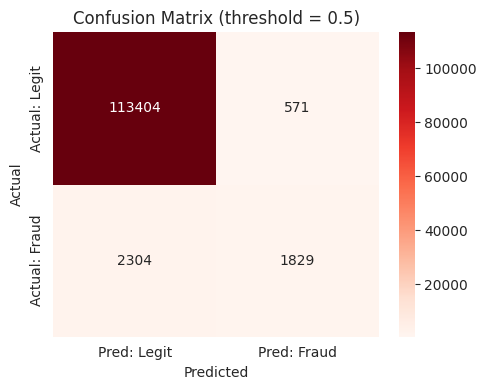

In [19]:
cm_05 = confusion_matrix(y_test, y_pred_05)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_05, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Pred: Legit', 'Pred: Fraud'], yticklabels=['Actual: Legit', 'Actual: Fraud'])
ax.set_title('Confusion Matrix (threshold = 0.5)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 12. Threshold Tuning

Rather than automatically using the default 0.5 threshold, we evaluate a range of thresholds and see how precision, recall, and the false positive/negative counts shift. **Lower thresholds** flag more transactions as fraud — catching more real fraud (higher recall) at the cost of more false alarms. **Higher thresholds** are more conservative — fewer false alarms, but more missed fraud.

We identify the threshold that maximizes F1-score purely as a *technical reference point*. In practice, a real financial institution would choose its operating threshold based on business costs (cost of a missed fraud vs. cost of a false decline), operational review capacity, and risk tolerance — not simply by maximizing a single statistical metric.


In [20]:
thresholds = np.arange(0.10, 0.91, 0.10)
rows = []
for t in thresholds:
    preds_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    rows.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, preds_t, zero_division=0),
        'recall': recall_score(y_test, preds_t, zero_division=0),
        'f1_score': f1_score(y_test, preds_t, zero_division=0),
        'false_positives': fp,
        'false_negatives': fn
    })

threshold_df = pd.DataFrame(rows).round(4)
threshold_df

,threshold,precision,recall,f1_score,false_positives,false_negatives
0,0.1,0.1787,0.8033,0.2924,15256,813
1,0.2,0.3550,0.6605,0.4618,4961,1403
2,0.3,0.5298,0.5720,0.5501,2098,1769
3,0.4,0.6628,0.5008,0.5706,1053,2063
4,0.5,0.7621,0.4425,0.5599,571,2304
5,0.6,0.8348,0.3912,0.5328,320,2516
6,0.7,0.8880,0.3397,0.4914,177,2729
7,0.8,0.9170,0.2780,0.4267,104,2984
8,0.9,0.9371,0.1982,0.3271,55,3314


In [21]:
best_row = threshold_df.loc[threshold_df['f1_score'].idxmax()]
print(f"Threshold that maximizes F1-score (technical reference point only): "
      f"{best_row['threshold']} (F1 = {best_row['f1_score']:.4f})")
print("A real deployment would instead weigh this against the business cost of false positives "
      "vs. false negatives, and the fraud team's actual review capacity.")

Threshold that maximizes F1-score (technical reference point only): 0.4 (F1 = 0.5706)
A real deployment would instead weigh this against the business cost of false positives vs. false negatives, and the fraud team's actual review capacity.


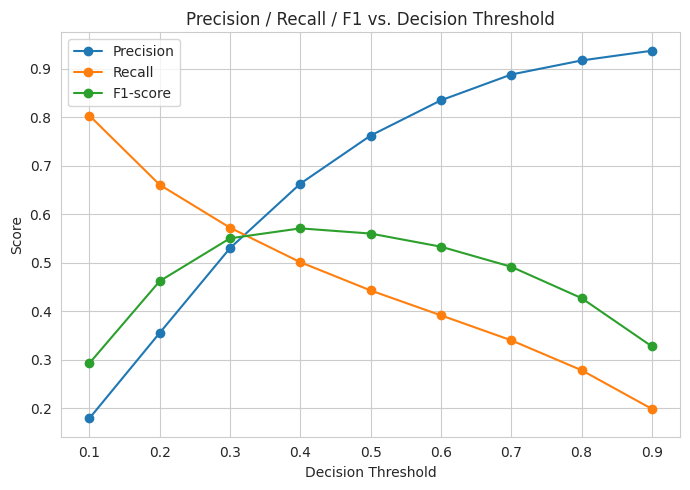

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
ax.plot(threshold_df['threshold'], threshold_df['f1_score'], marker='o', label='F1-score')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. Decision Threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Feature Importance

XGBoost provides a built-in feature importance score for each input feature (how often/effectively it was used to split trees across the ensemble). We show the top 20 most important features. **This shows which features the model relied on most, not that those features cause fraud** — several of the `V` columns are anonymized engineered features, so their real-world meaning is unknown to us; we can only interpret their statistical importance to the model, not their business meaning.


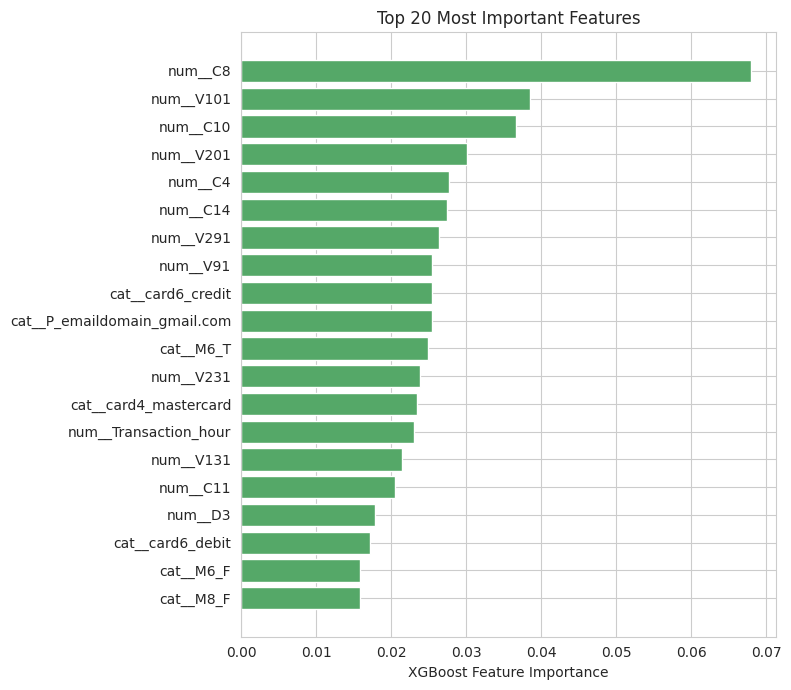

,feature,importance
15,num__C8,0.067914
47,num__V101,0.038451
17,num__C10,0.036665
57,num__V201,0.030059
11,num__C4,0.027654
21,num__C14,0.027413
66,num__V291,0.026445
46,num__V91,0.025460
82,cat__card6_credit,0.025442
91,cat__P_emaildomain_gmail.com,0.025435


In [23]:
importances = xgb_model.feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
top_features = importance_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_features['feature'], top_features['importance'], color='#55A868')
ax.set_xlabel('XGBoost Feature Importance')
ax.set_title('Top 20 Most Important Features')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_features

## 14. ROC Curve

The ROC curve plots the true positive rate against the false positive rate across every possible threshold. ROC-AUC summarizes this into a single number: the probability the model ranks a random fraud transaction above a random legitimate one.


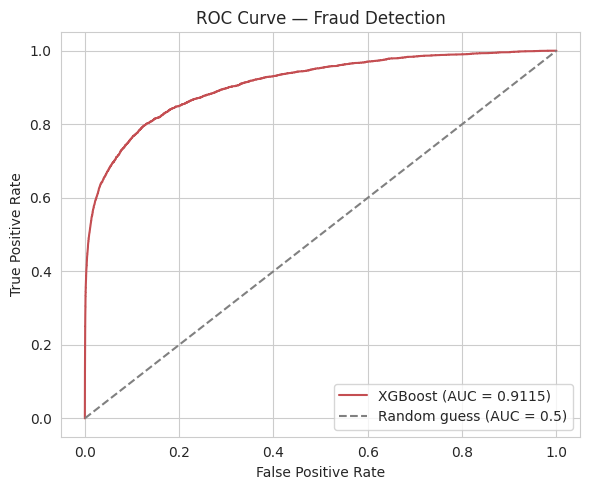

With a ROC-AUC of 0.9115, the model shows strong ability to rank fraudulent transactions above legitimate ones across the full range of thresholds. For heavily imbalanced problems like this one, it is also worth noting that Precision-Recall AUC can sometimes tell a more sensitive story than ROC-AUC, since ROC-AUC can look optimistic when negatives vastly outnumber positives — though the assignment's required metrics (ROC-AUC, precision, recall, F1) are reported above and remain the primary evaluation here.


In [24]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#C44E52', label=f'XGBoost (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Fraud Detection')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"With a ROC-AUC of {auc:.4f}, the model shows strong ability to rank fraudulent "
      f"transactions above legitimate ones across the full range of thresholds. "
      f"For heavily imbalanced problems like this one, it is also worth noting that "
      f"Precision-Recall AUC can sometimes tell a more sensitive story than ROC-AUC, "
      f"since ROC-AUC can look optimistic when negatives vastly outnumber positives — "
      f"though the assignment's required metrics (ROC-AUC, precision, recall, F1) are "
      f"reported above and remain the primary evaluation here.")

## 15. Confusion Matrix — Labeled

Using the same threshold = 0.5 reference point as the baseline evaluation, labeled explicitly in fraud-detection terms:

- **True Positive (TP):** Fraud correctly caught.
- **False Positive (FP):** Legitimate transaction incorrectly flagged as fraud.
- **True Negative (TN):** Legitimate transaction correctly passed through.
- **False Negative (FN):** Fraud that slipped through undetected.


True Positives (fraud caught):        1829
False Positives (legit flagged):      571
True Negatives (legit passed):        113404
False Negatives (fraud missed):       2304


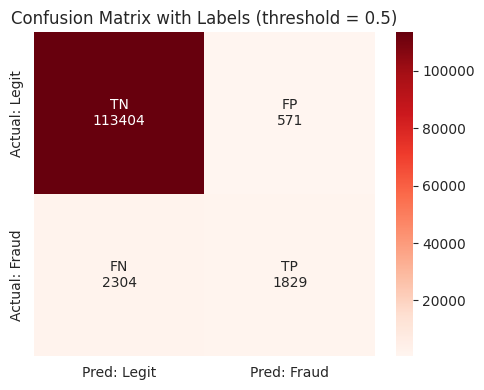

In [25]:
tn, fp, fn, tp = cm_05.ravel()
print(f"True Positives (fraud caught):        {tp}")
print(f"False Positives (legit flagged):      {fp}")
print(f"True Negatives (legit passed):        {tn}")
print(f"False Negatives (fraud missed):       {fn}")

fig, ax = plt.subplots(figsize=(5, 4))
labels = np.array([[f'TN\n{tn}', f'FP\n{fp}'], [f'FN\n{fn}', f'TP\n{tp}']])
sns.heatmap(cm_05, annot=labels, fmt='', cmap='Reds', ax=ax,
            xticklabels=['Pred: Legit', 'Pred: Fraud'], yticklabels=['Actual: Legit', 'Actual: Fraud'])
ax.set_title('Confusion Matrix with Labels (threshold = 0.5)')
plt.tight_layout()
plt.show()

## 16. Real-World Interpretation

- **False negatives (missed fraud)** translate directly into **financial loss** — the fraudulent charge goes through and typically must be reimbursed once discovered, plus the operational cost of investigating and reversing it.
- **False positives (legitimate transactions flagged)** create **customer friction** — a declined purchase, a temporarily blocked card, or a transaction sent for manual review, any of which can frustrate a genuine customer and damage trust in the platform.
- Every flagged transaction, true or false, typically adds to the **fraud team's manual review workload**, so the volume of flags (driven by the chosen threshold) has a direct **operational cost** as well as a customer-experience cost.

We deliberately do **not** attach specific rupee/dollar figures to these consequences, since the dataset gives us no real transaction-value-weighted cost model — in practice, a financial institution would combine this kind of model output with its own internal cost data to choose an operating point.


## 17. Limitations

- **Class imbalance remains challenging.** Even with SMOTE, this is a hard problem: fraud patterns are rare and subtle.
- **Synthetic samples are not real transactions.** SMOTE-generated fraud examples are interpolations between real fraud cases in feature space — they can help the model learn a broader fraud "region," but they are not genuine transactions and could introduce their own artifacts.
- **Historical, static dataset.** This is a snapshot of transactions from a specific period; real fraud patterns evolve over time (**concept drift**), so a model like this would need periodic retraining in production.
- **Feature subset used.** For memory/compute reasons on a normal laptop, we used a documented, reproducible subset of the 339 anonymized `V` columns rather than all of them — a full-scale production system could likely extract more signal from the complete feature set (or dedicated feature-engineering) with sufficient compute.
- **No causal claims.** Feature importance identifies statistical patterns the model relied on, not causal drivers of fraud.
- **Computational constraints.** Hyperparameters were chosen to keep training time reasonable on limited hardware rather than exhaustively tuned; a more thorough grid/Bayesian search could likely improve results further.
- **External validation required.** Before any real deployment, this kind of model would need validation on more recent data, a proper cost-sensitive threshold decision process, and ongoing monitoring.


## 18. Final Conclusion

In [26]:
print("=== Case Study 2 Summary ===")
print(f"Objective: Detect fraudulent transactions in the IEEE-CIS dataset")
print(f"Preprocessing: {len(numeric_features)} numeric + {len(categorical_features)} categorical "
      f"raw features -> {len(feature_names)} features after encoding")
print(f"Class balance handling: SMOTE applied to training data only "
      f"({y_train.value_counts()[0]} legit / {y_train.value_counts()[1]} fraud "
      f"-> balanced to {pd.Series(y_train_res).value_counts()[0]} / {pd.Series(y_train_res).value_counts()[1]})")
print(f"Model: XGBoost (n_estimators=200, max_depth=6, learning_rate=0.1)")
print()
print(f"ROC-AUC (test set):   {auc:.4f}")
print(f"Precision (thr=0.5):  {prec:.4f}")
print(f"Recall (thr=0.5):     {rec:.4f}")
print(f"F1-score (thr=0.5):   {f1:.4f}")
print(f"F1-optimal threshold: {best_row['threshold']} (F1 = {best_row['f1_score']:.4f})")
print()
print("The XGBoost model, trained on SMOTE-balanced data and evaluated on an untouched, "
      "realistically-imbalanced test set, achieves strong separation between fraud and "
      "legitimate transactions (ROC-AUC above). The threshold analysis shows a clear "
      "precision/recall trade-off that a real fraud team would tune based on their own "
      "review capacity and cost tolerance, rather than a single fixed cutoff. Feature "
      "importance highlights which engineered transaction/identity signals the model "
      "relied on most, though several remain anonymized and cannot be interpreted "
      "beyond their statistical contribution. As with any fraud model, this one would "
      "need ongoing monitoring and periodic retraining to remain effective as fraud "
      "patterns evolve.")

=== Case Study 2 Summary ===
Objective: Detect fraudulent transactions in the IEEE-CIS dataset
Preprocessing: 72 numeric + 23 categorical raw features -> 137 features after encoding
Class balance handling: SMOTE applied to training data only (455902 legit / 16530 fraud -> balanced to 455902 / 455902)
Model: XGBoost (n_estimators=200, max_depth=6, learning_rate=0.1)

ROC-AUC (test set):   0.9115
Precision (thr=0.5):  0.7621
Recall (thr=0.5):     0.4425
F1-score (thr=0.5):   0.5599
F1-optimal threshold: 0.4 (F1 = 0.5706)

The XGBoost model, trained on SMOTE-balanced data and evaluated on an untouched, realistically-imbalanced test set, achieves strong separation between fraud and legitimate transactions (ROC-AUC above). The threshold analysis shows a clear precision/recall trade-off that a real fraud team would tune based on their own review capacity and cost tolerance, rather than a single fixed cutoff. Feature importance highlights which engineered transaction/identity signals the mode